In [41]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

BASE_DIR      = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'TensorFlow : {tf.__version__}')
print(f'PROCESSED  : {PROCESSED_DIR}')
print(f'MODEL_DIR  : {MODEL_DIR}')

TensorFlow : 2.21.0
PROCESSED  : c:\Users\akbar\VSCode Project\RaksaDana\data\processed
MODEL_DIR  : c:\Users\akbar\VSCode Project\RaksaDana\models


In [42]:
with open(os.path.join(PROCESSED_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

sequences     = data['sequences']
scalers       = data['scalers']
feature_cols  = data['feature_cols']
target_col    = data['target_col']
target_idx    = data['target_idx']
window_size   = data['window_size']
tickers       = data['tickers']
featured_data = data['featured_data']

# zero-out fitur konstan — nilainya 0.0 semua setelah scaling, tapi eksplisit di-mask
ZERO_VAR_COLS = ['ROE', 'EPS', 'DY']
zero_idx = [feature_cols.index(c) for c in ZERO_VAR_COLS if c in feature_cols]

for ticker in tickers:
    for split in ('X_train', 'X_test'):
        sequences[ticker][split][:, :, zero_idx] = 0.0

print(f'Tickers     : {tickers}')
print(f'Features    : {len(feature_cols)} cols (masked: {ZERO_VAR_COLS})')
print(f'Target      : {target_col} (idx={target_idx})')
print(f'Window size : {window_size}')
for t in tickers:
    s = sequences[t]
    print(f'{t} -> X_train {s["X_train"].shape}  X_test {s["X_test"].shape}')

Tickers     : ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']
Features    : 20 cols (masked: ['ROE', 'EPS', 'DY'])
Target      : Close (idx=3)
Window size : 60
BBCA.JK -> X_train (1100, 60, 20)  X_test (276, 60, 20)
BBRI.JK -> X_train (1100, 60, 20)  X_test (276, 60, 20)
BMRI.JK -> X_train (1100, 60, 20)  X_test (276, 60, 20)


## Model Architecture

In [43]:
from tensorflow.keras.regularizers import l2

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(32, return_sequences=True,
             kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(16, return_sequences=False,
             kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.1),

        Dense(8, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='huber',
        metrics=['mae']
    )
    return model

sample_shape = (window_size, len(feature_cols))
build_lstm(sample_shape).summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 60, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 60, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 60, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,905 (148.07 KB)

 Trainable params: 37,681 (147.19 KB)

 Non-trainable params: 224 (896.00 B)

## Training

In [44]:
EPOCHS     = 100
BATCH_SIZE = 32

histories = {}
models    = {}

for ticker in tickers:
    print(f'\n{"="*50}')
    print(f'Training: {ticker}')
    print(f'{"="*50}')

    s       = sequences[ticker]
    X_train = s['X_train']
    y_train = s['y_train']
    X_test  = s['X_test']
    y_test  = s['y_test']

    model = build_lstm((window_size, len(feature_cols)))

    ckpt_path = os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".","_")}_best.keras')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=0)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    histories[ticker] = history.history
    models[ticker]    = model
    print(f'Saved: {ckpt_path}')


Training: BBCA.JK
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.3692 - mae: 0.7007 - val_loss: 0.1085 - val_mae: 0.3900 - learning_rate: 0.0010
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.1217 - mae: 0.3544 - val_loss: 0.0797 - val_mae: 0.3098 - learning_rate: 0.0010
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0888 - mae: 0.2865 - val_loss: 0.0696 - val_mae: 0.2772 - learning_rate: 0.0010
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0712 - mae: 0.2420 - val_loss: 0.0477 - val_mae: 0.1843 - learning_rate: 0.0010
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0636 - mae: 0.2182 - val_loss: 0.0417 - val_mae: 0.1507 - learning_rate: 0.0010
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0570 - mae: 0.2001 - val_loss: 0.0355 - val_mae: 0.1089 - learning_rate: 0.0010
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0544 - mae: 0.1865 - val_loss: 0.0322 - val_mae: 0.0823 - learning_

## Training Curves

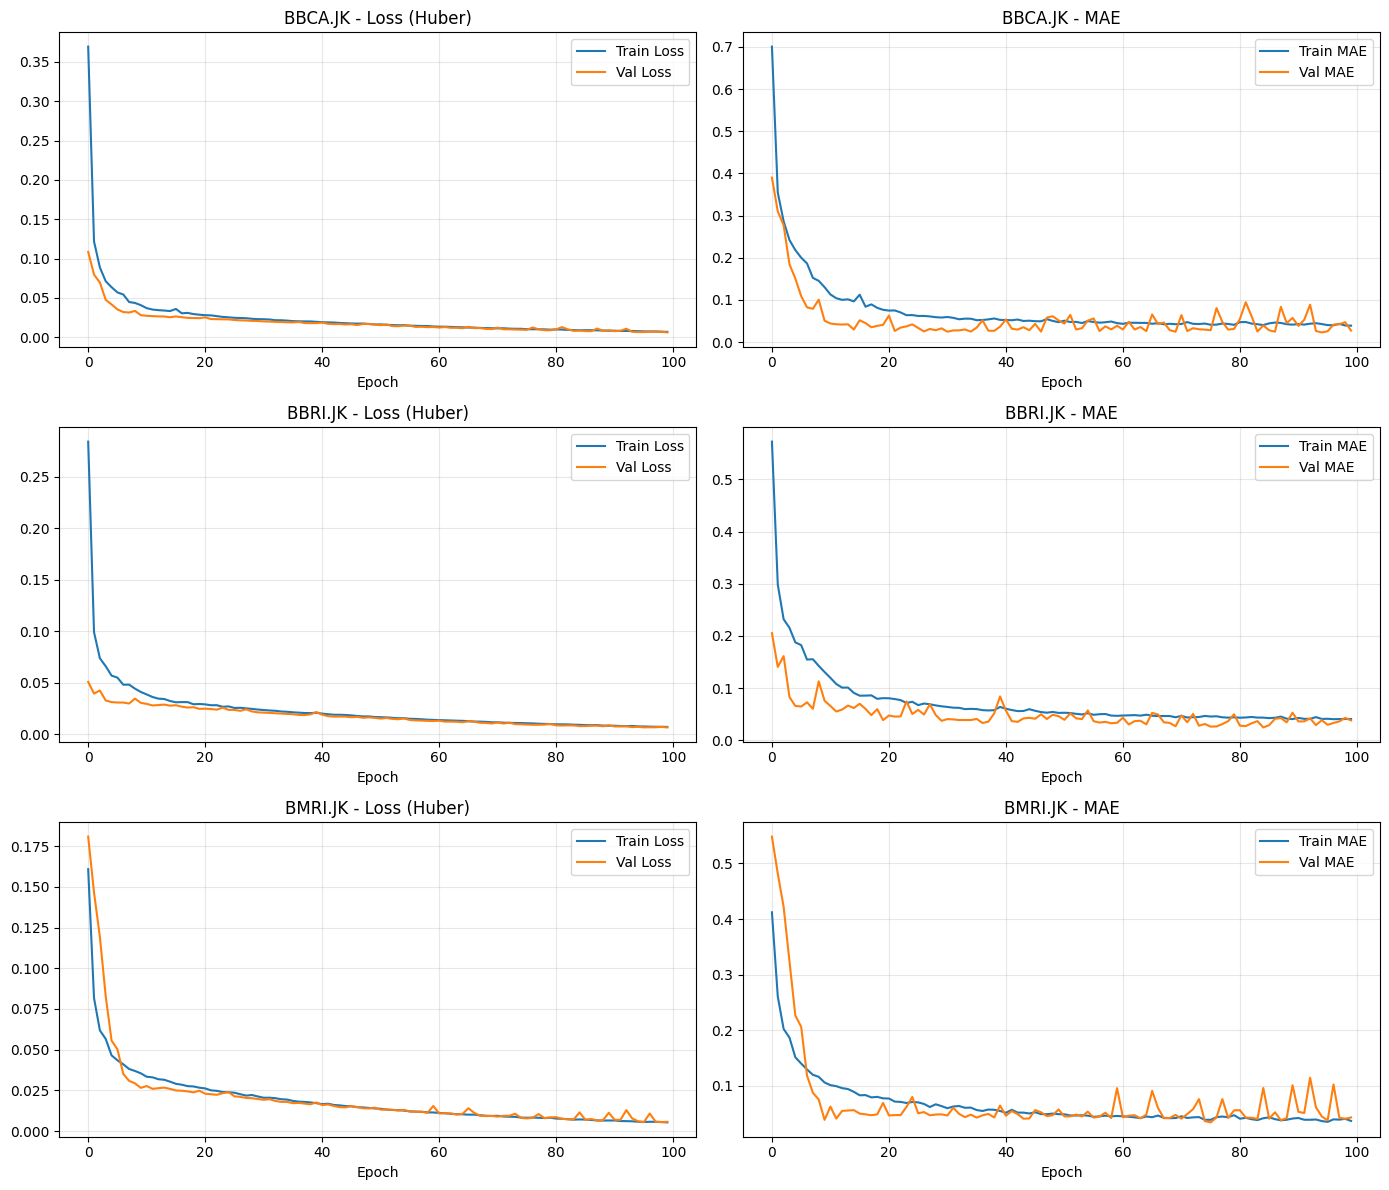

In [45]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    h = histories[ticker]

    axes[i, 0].plot(h['loss'],     label='Train Loss')
    axes[i, 0].plot(h['val_loss'], label='Val Loss')
    axes[i, 0].set_title(f'{ticker} - Loss (Huber)')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(h['mae'],     label='Train MAE')
    axes[i, 1].plot(h['val_mae'], label='Val MAE')
    axes[i, 1].set_title(f'{ticker} - MAE')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## Inverse-Transform Predictions

In [46]:
def inverse_close(scaler, scaled_values, n_features, target_idx):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

predictions = {}
n_feat = len(feature_cols)

for ticker in tickers:
    s      = sequences[ticker]
    scaler = scalers[ticker]
    model  = models[ticker]

    y_pred_scaled = model.predict(s['X_test'],  verbose=0)
    y_tr_scaled   = model.predict(s['X_train'], verbose=0)

    predictions[ticker] = {
        'y_true':       inverse_close(scaler, s['y_test'],       n_feat, target_idx),
        'y_pred':       inverse_close(scaler, y_pred_scaled,     n_feat, target_idx),
        'y_train_true': inverse_close(scaler, s['y_train'],      n_feat, target_idx),
        'y_train_pred': inverse_close(scaler, y_tr_scaled,       n_feat, target_idx),
    }

print('Inverse transform done.')

Inverse transform done.


## Evaluation Metrics

In [47]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

rows = []
for ticker in tickers:
    p = predictions[ticker]
    rows.append({'Ticker': ticker, 'Split': 'Train', **evaluate(p['y_train_true'], p['y_train_pred'])})
    rows.append({'Ticker': ticker, 'Split': 'Test',  **evaluate(p['y_true'],       p['y_pred'])})

metrics_df = pd.DataFrame(rows).set_index(['Ticker', 'Split'])
metrics_df = metrics_df.round({'MAE': 2, 'RMSE': 2, 'MAPE': 4, 'R2': 4})

display(
    metrics_df.style
        .background_gradient(subset=['MAE','RMSE','MAPE'], cmap='RdYlGn_r')
        .background_gradient(subset=['R2'], cmap='RdYlGn')
        .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'})
)

## Prediction vs Actual

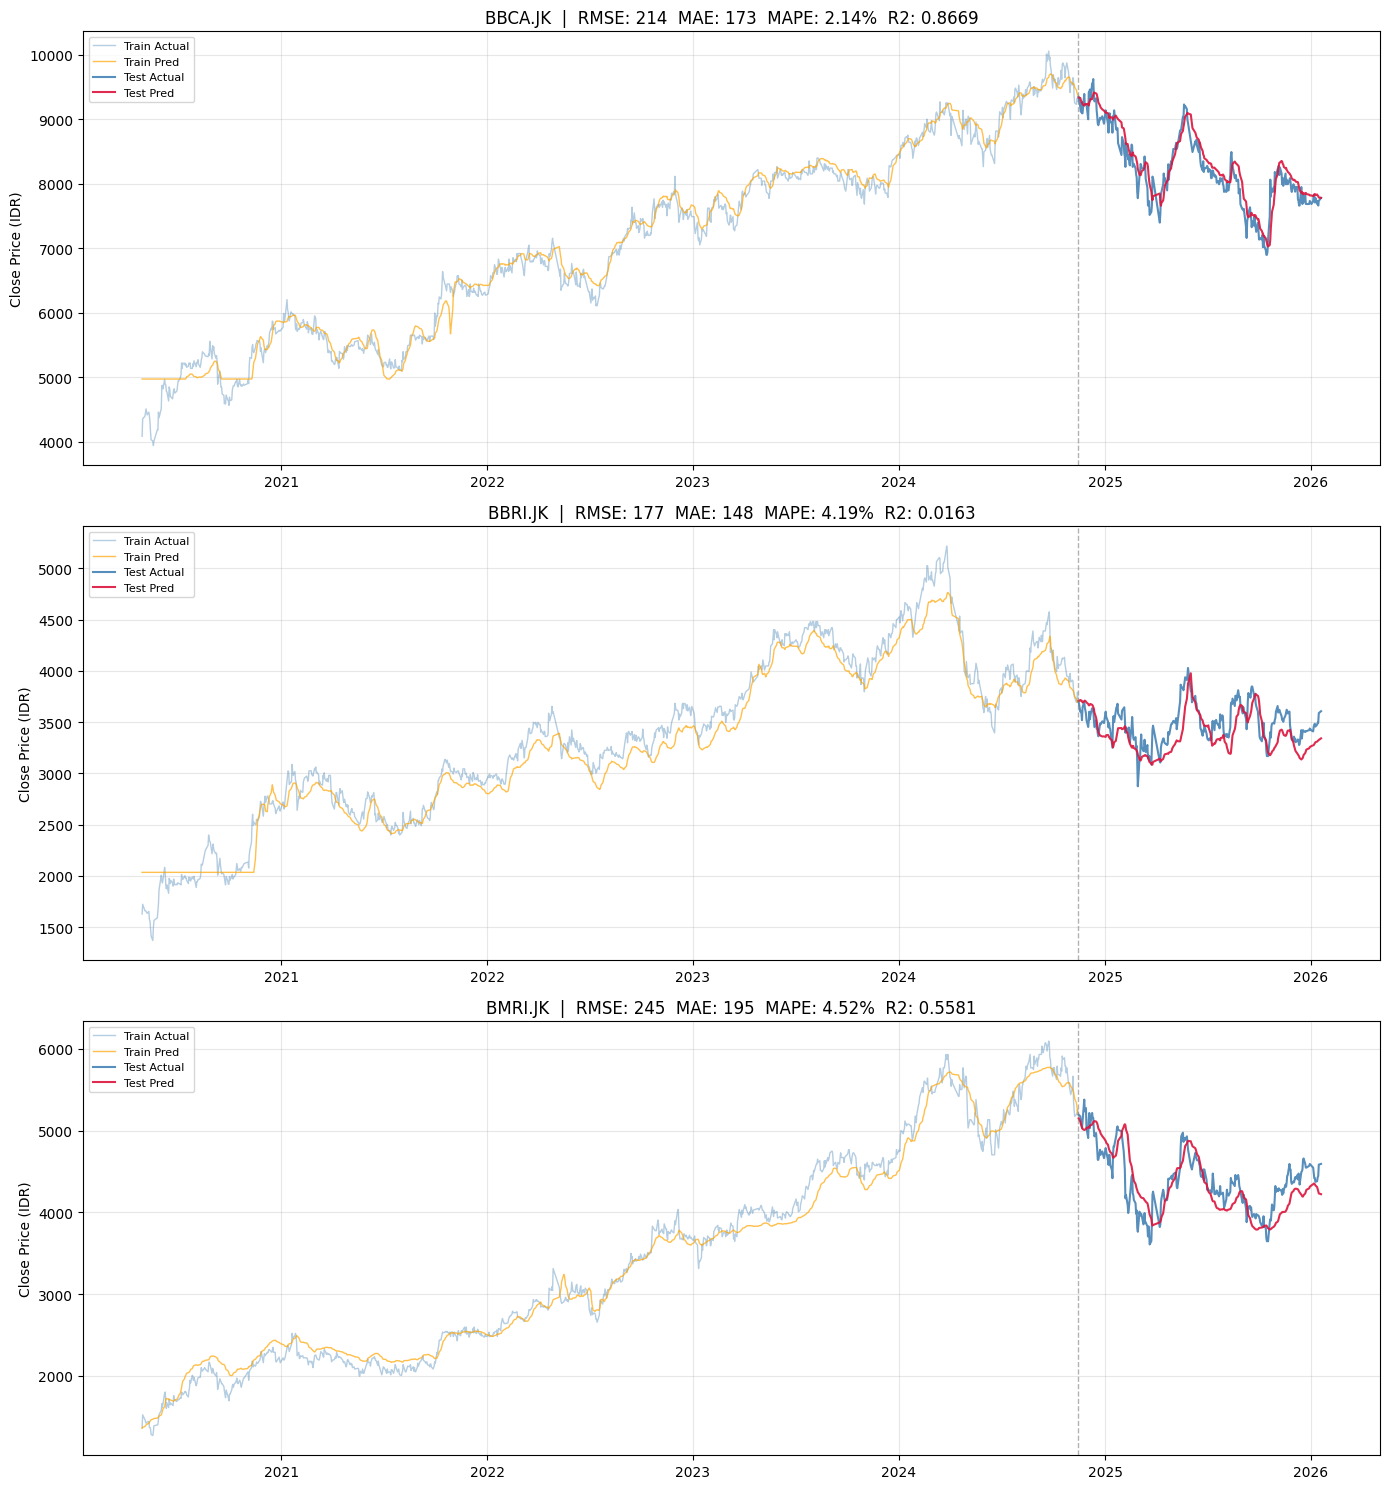

In [48]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 5 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    split = len(p['y_train_true'])

    train_dates = dates[window_size : window_size + split]
    test_dates  = dates[window_size + split : window_size + split + len(p['y_true'])]

    ax.plot(train_dates, p['y_train_true'], color='steelblue', alpha=0.4, lw=1,   label='Train Actual')
    ax.plot(train_dates, p['y_train_pred'], color='orange',    alpha=0.7, lw=1,   label='Train Pred')
    ax.plot(test_dates,  p['y_true'],       color='steelblue', alpha=0.9, lw=1.5, label='Test Actual')
    ax.plot(test_dates,  p['y_pred'],       color='crimson',   alpha=0.9, lw=1.5, label='Test Pred')
    ax.axvline(train_dates[-1], color='gray', linestyle='--', lw=1, alpha=0.6)

    m = evaluate(p['y_true'], p['y_pred'])
    ax.set_title(f"{ticker}  |  RMSE: {m['RMSE']:,.0f}  MAE: {m['MAE']:,.0f}  MAPE: {m['MAPE']:.2f}%  R2: {m['R2']:.4f}")
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'prediction_vs_actual.png'), dpi=120, bbox_inches='tight')
plt.show()

## Test Set Zoom

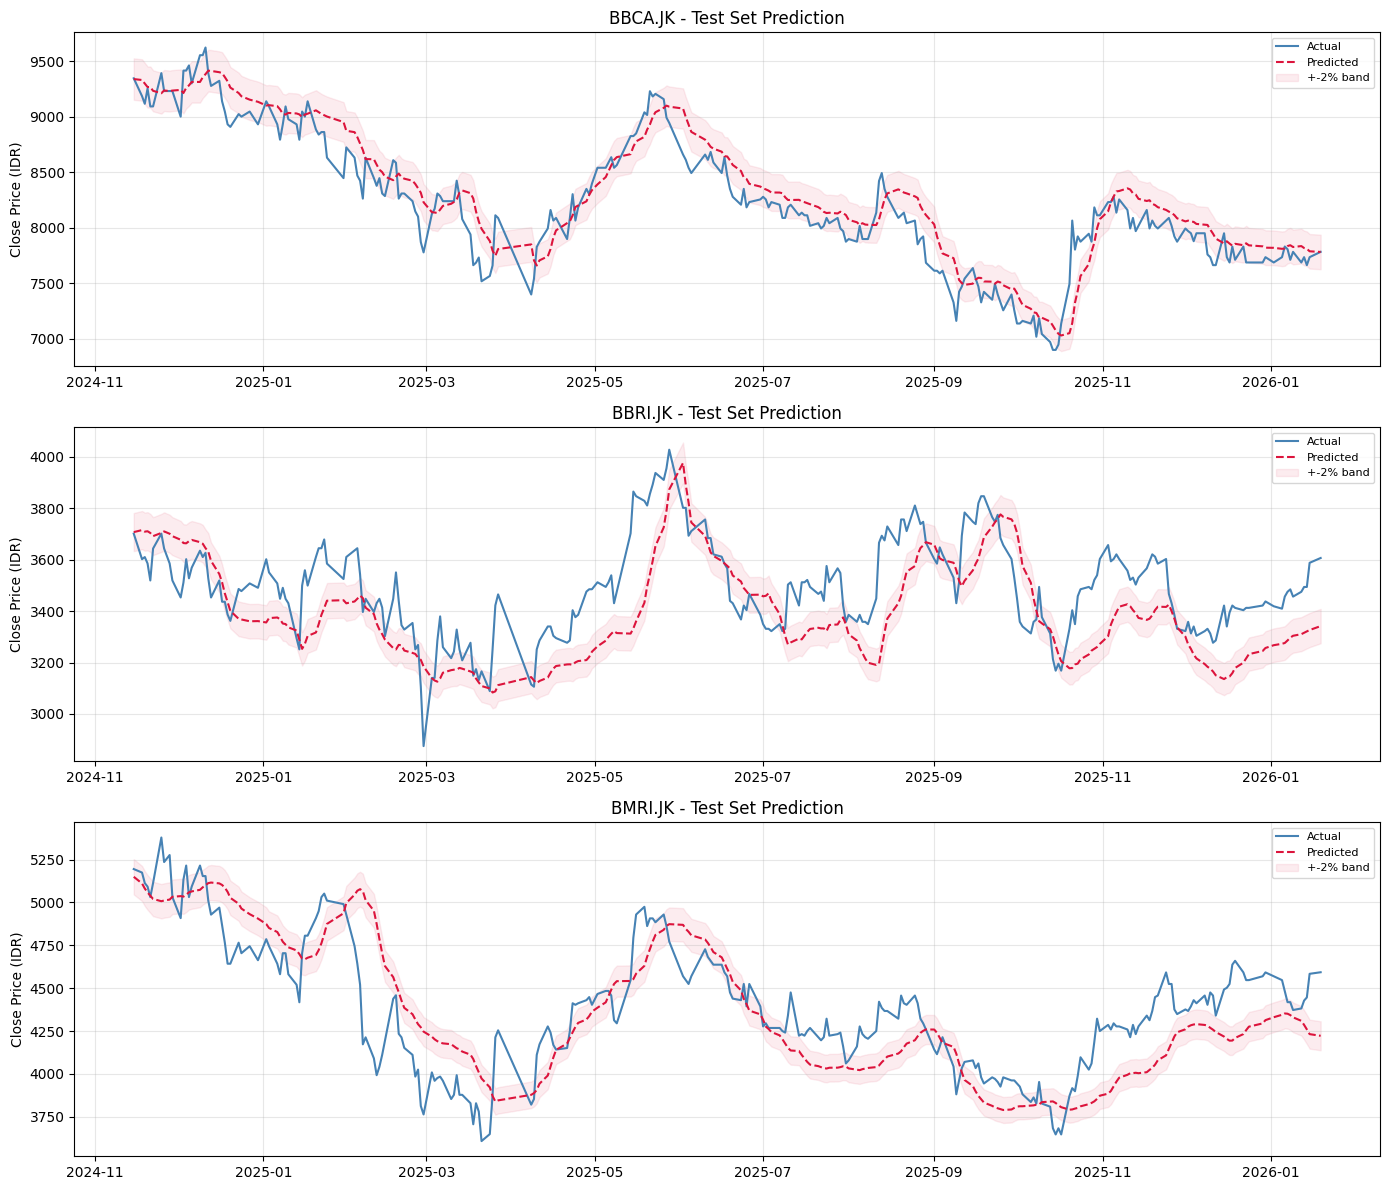

In [49]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    split = len(p['y_train_true'])
    test_dates = dates[window_size + split : window_size + split + len(p['y_true'])]

    ax.plot(test_dates, p['y_true'], color='steelblue', lw=1.5, label='Actual')
    ax.plot(test_dates, p['y_pred'], color='crimson',   lw=1.5, label='Predicted', linestyle='--')
    ax.fill_between(test_dates, p['y_pred'] * 0.98, p['y_pred'] * 1.02,
                    color='crimson', alpha=0.08, label='+-2% band')
    ax.set_title(f'{ticker} - Test Set Prediction')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'test_zoom.png'), dpi=120, bbox_inches='tight')
plt.show()

## Residual Analysis

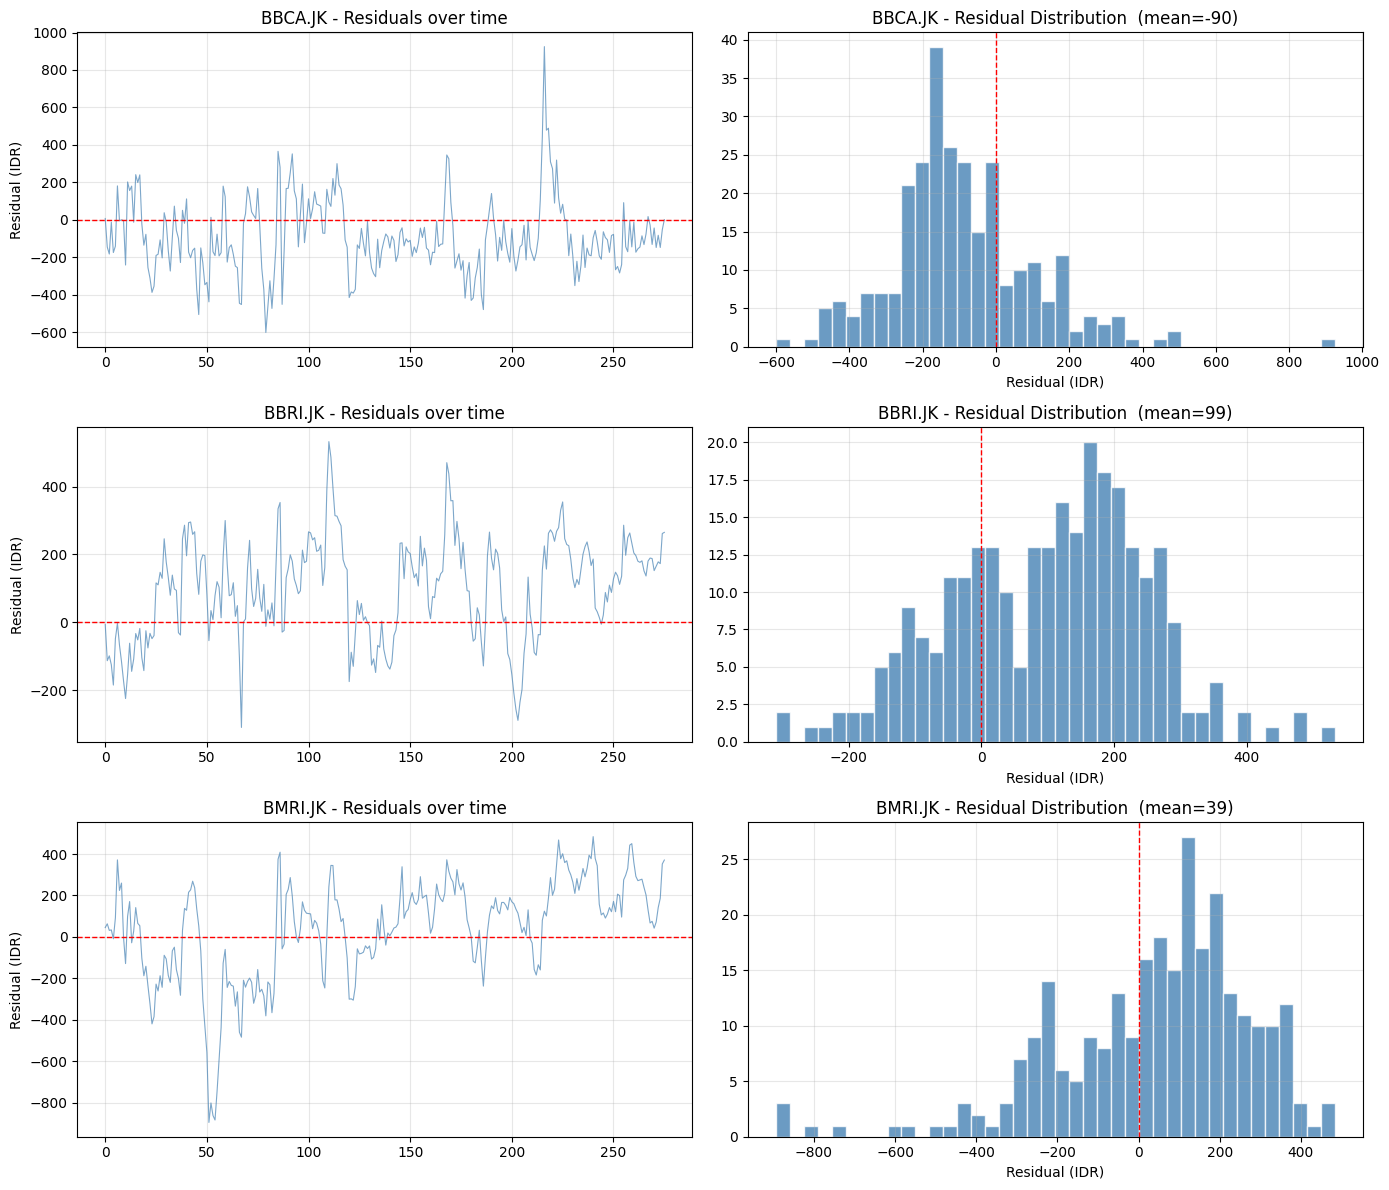

In [50]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p         = predictions[ticker]
    residuals = p['y_true'] - p['y_pred']

    axes[i, 0].plot(residuals, color='steelblue', lw=0.8, alpha=0.7)
    axes[i, 0].axhline(0, color='red', linestyle='--', lw=1)
    axes[i, 0].set_title(f'{ticker} - Residuals over time')
    axes[i, 0].set_ylabel('Residual (IDR)')
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 1].axvline(0, color='red', linestyle='--', lw=1)
    axes[i, 1].set_title(f'{ticker} - Residual Distribution  (mean={residuals.mean():,.0f})')
    axes[i, 1].set_xlabel('Residual (IDR)')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'residuals.png'), dpi=120, bbox_inches='tight')
plt.show()

## Directional Accuracy

In [51]:
da_rows = []
for ticker in tickers:
    p = predictions[ticker]
    actual_dir = np.sign(np.diff(p['y_true']))
    pred_dir   = np.sign(np.diff(p['y_pred']))
    da = (actual_dir == pred_dir).mean() * 100
    da_rows.append({'Ticker': ticker, 'Directional Accuracy (%)': round(da, 2)})

da_df = pd.DataFrame(da_rows).set_index('Ticker')
display(da_df.style.background_gradient(cmap='RdYlGn', vmin=40, vmax=70))

,Directional Accuracy (%)
Ticker,
BBCA.JK,44.000000
BBRI.JK,50.550000
BMRI.JK,46.550000


## 30-Day Forecast

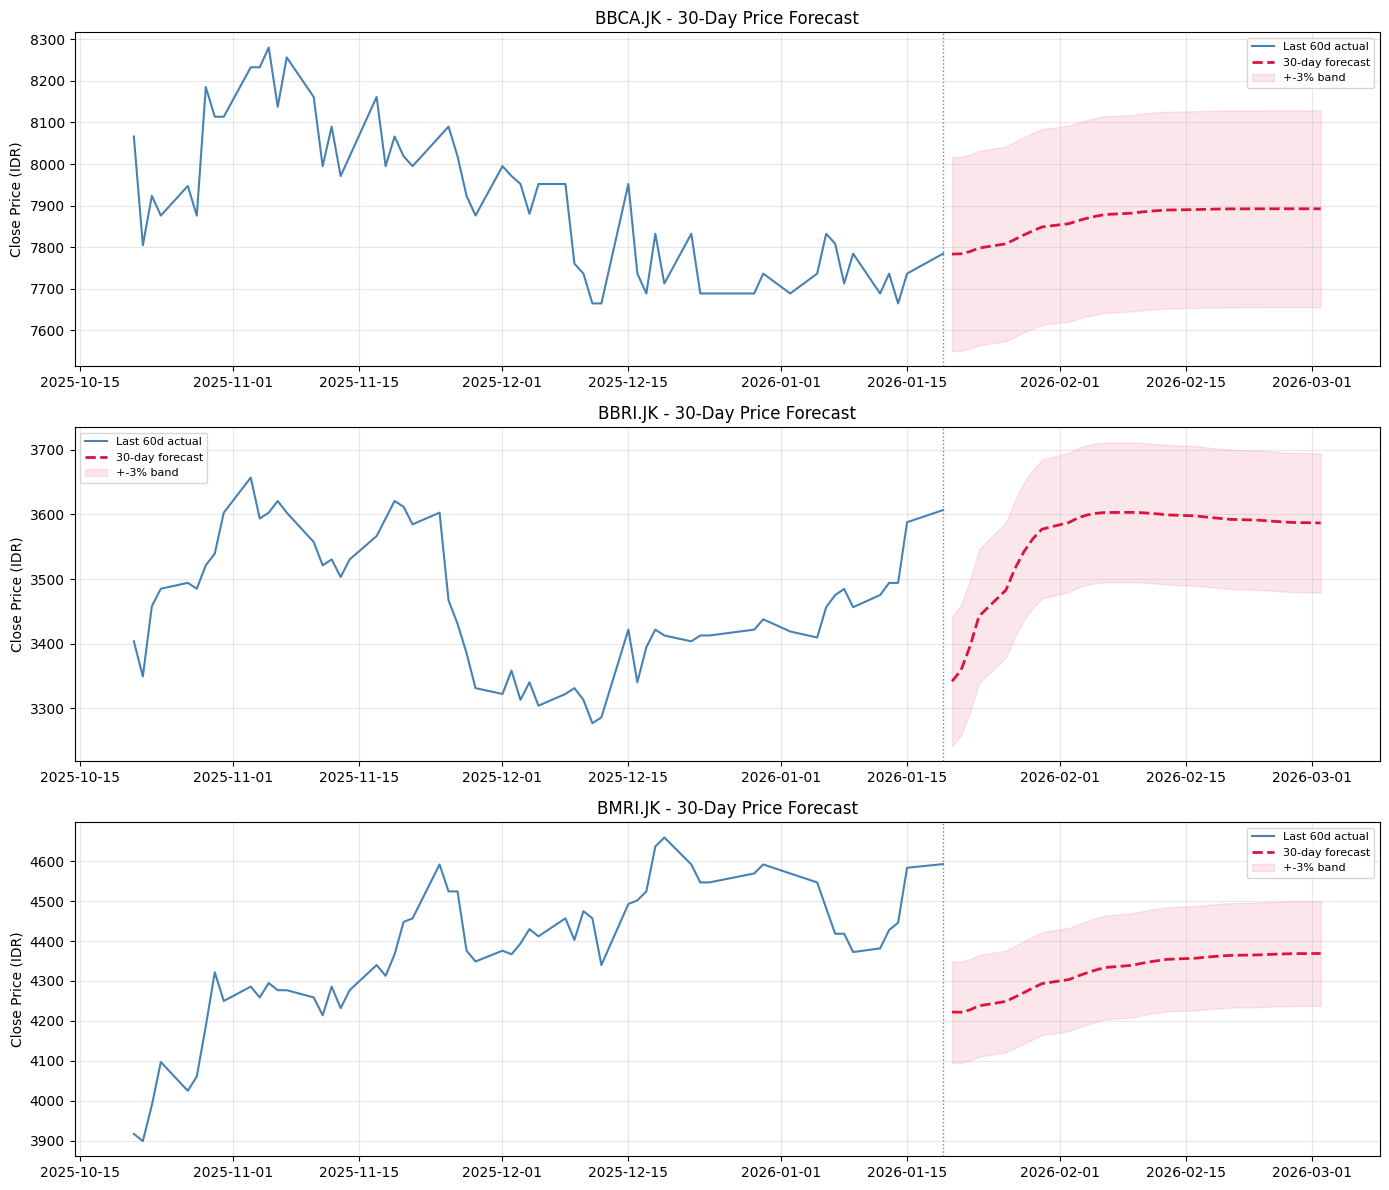

In [52]:
FORECAST_DAYS = 30

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    s      = sequences[ticker]
    scaler = scalers[ticker]
    model  = models[ticker]
    ax     = axes[i]

    last_window     = s['X_test'][-1].copy()
    forecast_scaled = []

    for _ in range(FORECAST_DAYS):
        pred = model.predict(last_window[np.newaxis], verbose=0)[0, 0]
        forecast_scaled.append(pred)
        new_step             = last_window[-1].copy()
        new_step[target_idx] = pred
        last_window          = np.vstack([last_window[1:], new_step])

    forecast     = inverse_close(scaler, np.array(forecast_scaled), len(feature_cols), target_idx)
    last_actuals = predictions[ticker]['y_true'][-60:]
    last_dates   = featured_data[ticker].index[-60:]
    future_dates = pd.bdate_range(start=last_dates[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

    ax.plot(last_dates,   last_actuals, color='steelblue', lw=1.5, label='Last 60d actual')
    ax.plot(future_dates, forecast,     color='crimson',   lw=2,   label=f'{FORECAST_DAYS}-day forecast', linestyle='--')
    ax.fill_between(future_dates, forecast * 0.97, forecast * 1.03,
                    color='crimson', alpha=0.1, label='+-3% band')
    ax.axvline(last_dates[-1], color='gray', linestyle=':', lw=1)
    ax.set_title(f'{ticker} - {FORECAST_DAYS}-Day Price Forecast')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'forecast_30d.png'), dpi=120, bbox_inches='tight')
plt.show()

## Summary

In [53]:
print('Final Test Metrics')
print('=' * 60)
test_metrics = metrics_df.xs('Test', level='Split')
display(
    test_metrics.style.format(
        {'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'}
    )
)
print('\nDirectional Accuracy')
display(da_df)
print('\nModels saved:')
for ticker in tickers:
    p = os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".","_")}_best.keras')
    print(f'  {p}')

Final Test Metrics


,MAE,RMSE,MAPE,R2
Ticker,,,,
BBCA.JK,173.42,214.42,2.1382%,0.8669
BBRI.JK,147.61,177.49,4.1896%,0.0163
BMRI.JK,195.42,244.81,4.5216%,0.5581



Directional Accuracy


,Directional Accuracy (%)
Ticker,
BBCA.JK,44.00
BBRI.JK,50.55
BMRI.JK,46.55



Models saved:
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BBCA_JK_best.keras
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BBRI_JK_best.keras
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BMRI_JK_best.keras
